In [19]:
# @title Configuração de Ambiente
!pip -q install scikit-learn deap pandas seaborn matplotlib

import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Any, Optional
from dataclasses import dataclass

# Forçar uso de CPU e silenciar logs
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# Seeds para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('✅ Ambiente configurado com sucesso!')
print('📦 Bibliotecas: scikit-learn, DEAP, pandas, seaborn, matplotlib')
# Saída Esperada: ✅ Ambiente configurado com sucesso!


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
✅ Ambiente configurado com sucesso!
📦 Bibliotecas: scikit-learn, DEAP, pandas, seaborn, matplotlib
✅ Ambiente configurado com sucesso!
📦 Bibliotecas: scikit-learn, DEAP, pandas, seaborn, matplotlib


# Workshop Prático: Laboratório de Fairness Testing
## Implementando Detectores de Viés com SBSE

Neste laboratório, você implementará um sistema completo de detecção de viés em modelos de Machine Learning usando algoritmos genéticos. Vamos aplicar conceitos de fairness testing em um caso prático: auditar um modelo de aprovação de crédito.

### Objetivos:
1. Implementar um algoritmo genético para detectar discriminação em modelos de ML
2. Aplicar diferentes métricas de fairness como funções de fitness
3. Analisar e interpretar resultados de fairness testing

### Estrutura do Laboratório:
- **Parte 1:** Configuração e Análise do Modelo Enviesado
- **Parte 2:** Implementação da Representação e Operadores SBSE
- **Parte 3:** Múltiplas Funções de Fitness para Fairness
- **Parte 4:** Execução dos Experimentos de Fairness Testing
- **Parte 5:** Análise de Resultados e Propostas de Mitigação

---
## Parte 1: Configuração e Análise do Modelo Enviesado

Nesta primeira parte, vamos criar um dataset sintético de aprovação de crédito com viés intencional e treinar um modelo que aprenderá esses vieses. Isso simula cenários reais onde modelos aprendem discriminação presente nos dados históricos.

In [20]:
# @title Geração de Dataset Sintético com Viés
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def create_biased_credit_dataset(n_samples: int = 5000) -> pd.DataFrame:
    """
    Cria um dataset sintético de aprovação de crédito com viés intencional.
    
    O viés é introduzido de forma que:
    - Mulheres têm menor probabilidade de aprovação mesmo com perfis similares
    - Pessoas da etnia 'PRETA' têm menor probabilidade de aprovação
    
    Parameters
    ----------
    n_samples : int
        Número de amostras a gerar
    
    Returns
    -------
    pd.DataFrame
        Dataset com atributos do cliente e rótulo de aprovação
    """
    rng = np.random.default_rng(SEED)
    
    # Gerar atributos básicos
    age = rng.integers(21, 66, size=n_samples)
    salary = rng.normal(60000, 18000, size=n_samples).clip(20000, 160000)
    credit_score = rng.integers(300, 851, size=n_samples)
    years_experience = np.clip(age - rng.integers(18, 36, size=n_samples), 0, 40)
    
    # Atributos sensíveis
    gender = rng.choice(['M', 'F'], size=n_samples, p=[0.5, 0.5])
    ethnicity = rng.choice(['BRANCA', 'PARDA', 'PRETA'], size=n_samples, p=[0.5, 0.3, 0.2])
    education = rng.choice(['MEDIO', 'SUPERIOR', 'POS_GRAD'], size=n_samples, p=[0.4, 0.4, 0.2])
    
    # Calcular score base (sem viés)
    base_score = (
        0.25 * (age / 65) +
        0.35 * (salary / 160000) +
        0.25 * (credit_score / 850) +
        0.15 * (years_experience / 40)
    )
    
    # Adicionar viés: penalizar mulheres e pessoas pretas
    bias_penalty = np.zeros(n_samples)
    bias_penalty[gender == 'F'] -= 0.15  # Mulheres sofrem penalidade de -0.15
    bias_penalty[ethnicity == 'PRETA'] -= 0.20  # Pessoas pretas sofrem penalidade de -0.20
    
    # Score final com viés
    final_score = base_score + bias_penalty
    
    # Gerar rótulo de aprovação (probabilidade baseada no score final)
    approval_prob = 1.0 / (1.0 + np.exp(-10 * (final_score - 0.5)))
    approved = (rng.random(n_samples) < approval_prob).astype(int)
    
    # Criar DataFrame
    df = pd.DataFrame({
        'age': age,
        'salary': salary,
        'credit_score': credit_score,
        'years_experience': years_experience,
        'gender': gender,
        'ethnicity': ethnicity,
        'education': education,
        'approved': approved
    })
    
    return df

# Gerar dataset
df = create_biased_credit_dataset(5000)

print(f'📦 Dataset gerado: {len(df)} linhas, {len(df.columns)-1} atributos')
print(f'\n📊 Primeiras linhas:')
print(df.head())

# Análise exploratória: verificar viés nas taxas de aprovação
print('\n⚖️ Taxa de aprovação por gênero:')
print(df.groupby('gender')['approved'].mean())

print('\n⚖️ Taxa de aprovação por etnia:')
print(df.groupby('ethnicity')['approved'].mean())

# Saída Esperada: Taxas de aprovação significativamente diferentes entre grupos

📦 Dataset gerado: 5000 linhas, 7 atributos

📊 Primeiras linhas:
   age        salary  credit_score  years_experience gender ethnicity  \
0   25  53230.124570           817                 0      F    BRANCA   
1   55  51754.527570           788                29      M     PRETA   
2   50  73841.385688           644                21      M     PRETA   
3   40  74743.875040           617                 7      F     PARDA   
4   40  50368.431239           498                17      M    BRANCA   

  education  approved  
0     MEDIO         0  
1     MEDIO         0  
2  SUPERIOR         0  
3     MEDIO         0  
4     MEDIO         1  

⚖️ Taxa de aprovação por gênero:
gender
F    0.224852
M    0.496957
Name: approved, dtype: float64

⚖️ Taxa de aprovação por etnia:
ethnicity
BRANCA    0.409762
PARDA     0.432895
PRETA     0.132438
Name: approved, dtype: float64
ethnicity
BRANCA    0.409762
PARDA     0.432895
PRETA     0.132438
Name: approved, dtype: float64


In [21]:
# @title Treinamento do Modelo Discriminatório

def train_credit_model(df: pd.DataFrame) -> Pipeline:
    """
    Treina um modelo de aprovação de crédito que aprenderá os vieses do dataset.
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset de treinamento
    
    Returns
    -------
    Pipeline
        Modelo treinado com pré-processamento
    """
    # Separar features e target
    X = df.drop('approved', axis=1)
    y = df['approved']
    
    # Definir colunas numéricas e categóricas
    numeric_features = ['age', 'salary', 'credit_score', 'years_experience']
    categorical_features = ['gender', 'ethnicity', 'education']
    
    # Pipeline de pré-processamento
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
        ]
    )
    
    # Pipeline completo: pré-processamento + modelo
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=SEED))
    ])
    
    # Treinar modelo
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
    model.fit(X_train, y_train)
    
    # Avaliar
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    print(f'🎯 Acurácia no treino: {train_score:.3f}')
    print(f'🎯 Acurácia no teste: {test_score:.3f}')
    
    return model, X_test, y_test

# Treinar modelo
credit_model, X_test, y_test = train_credit_model(df)

print('\n✅ Modelo treinado com sucesso!')
print('⚠️ Este modelo aprendeu os vieses presentes nos dados.')
# Saída Esperada: Acurácia ~0.85-0.90

🎯 Acurácia no treino: 1.000
🎯 Acurácia no teste: 0.742

✅ Modelo treinado com sucesso!
⚠️ Este modelo aprendeu os vieses presentes nos dados.


📊 Análise Estatística de Viés:

Disparidade de Gênero: 0.288
Disparidade Étnica (máxima): 0.312
Disparate Impact (gênero): 0.421

⚠️ Valores < 0.8 em Disparate Impact indicam discriminação segundo a regra 80%


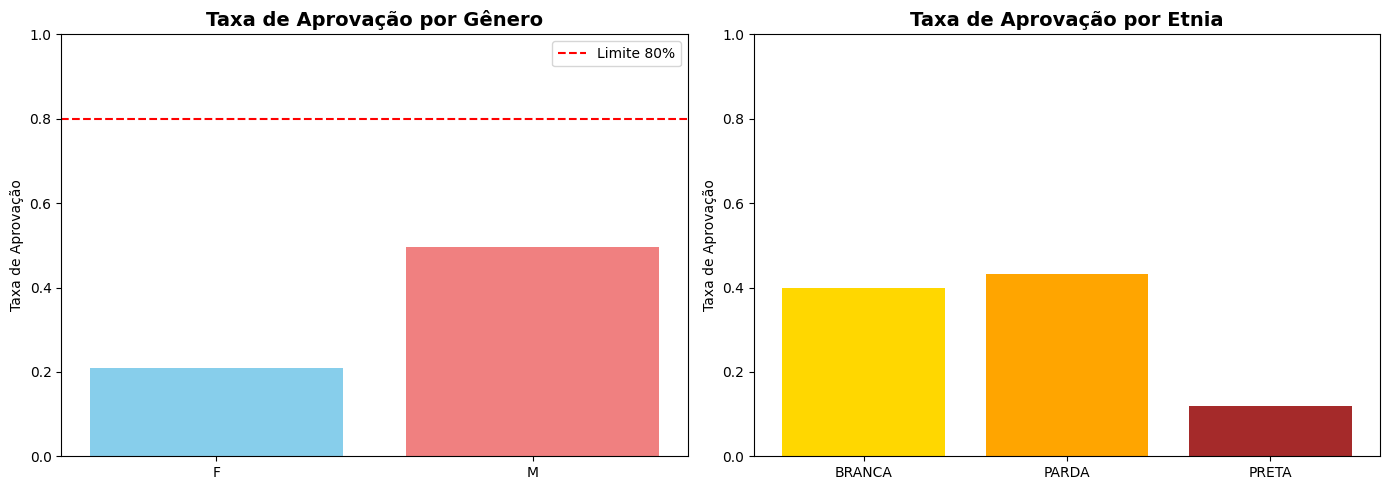


💡 Análise estatística simples detecta viés agregado, mas pode perder casos específicos.
🔍 SBSE nos permite buscar os casos MAIS discriminatórios de forma sistemática.


In [22]:
# @title Análise Estatística Inicial do Viés

def statistical_bias_analysis(model: Pipeline, df: pd.DataFrame) -> Dict[str, float]:
    """
    Realiza análise estatística simples para detectar viés no modelo.
    
    Esta é a abordagem tradicional que vamos comparar com SBSE.
    
    Parameters
    ----------
    model : Pipeline
        Modelo treinado
    df : pd.DataFrame
        Dataset para análise
    
    Returns
    -------
    Dict[str, float]
        Métricas de disparidade entre grupos
    """
    X = df.drop('approved', axis=1)
    predictions = model.predict(X)
    
    # Adicionar predições ao DataFrame
    df_analysis = df.copy()
    df_analysis['predicted'] = predictions
    
    # Calcular taxas de aprovação por grupo
    metrics = {}
    
    # Disparidade de gênero
    approval_by_gender = df_analysis.groupby('gender')['predicted'].mean()
    metrics['gender_disparity'] = abs(approval_by_gender['M'] - approval_by_gender['F'])
    
    # Disparidade étnica
    approval_by_ethnicity = df_analysis.groupby('ethnicity')['predicted'].mean()
    metrics['ethnicity_disparity_max'] = approval_by_ethnicity.max() - approval_by_ethnicity.min()
    
    # Disparate Impact (razão de aprovação entre grupos)
    metrics['disparate_impact_gender'] = approval_by_gender['F'] / approval_by_gender['M']
    
    return metrics, df_analysis

# Realizar análise
bias_metrics, df_with_predictions = statistical_bias_analysis(credit_model, df)

print('📊 Análise Estatística de Viés:\n')
print(f"Disparidade de Gênero: {bias_metrics['gender_disparity']:.3f}")
print(f"Disparidade Étnica (máxima): {bias_metrics['ethnicity_disparity_max']:.3f}")
print(f"Disparate Impact (gênero): {bias_metrics['disparate_impact_gender']:.3f}")
print('\n⚠️ Valores < 0.8 em Disparate Impact indicam discriminação segundo a regra 80%')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de aprovação por gênero
approval_gender = df_with_predictions.groupby('gender')['predicted'].mean()
axes[0].bar(approval_gender.index, approval_gender.values, color=['skyblue', 'lightcoral'])
axes[0].set_title('Taxa de Aprovação por Gênero', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Taxa de Aprovação')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.8, color='red', linestyle='--', label='Limite 80%')
axes[0].legend()

# Taxa de aprovação por etnia
approval_ethnicity = df_with_predictions.groupby('ethnicity')['predicted'].mean()
axes[1].bar(approval_ethnicity.index, approval_ethnicity.values, color=['gold', 'orange', 'brown'])
axes[1].set_title('Taxa de Aprovação por Etnia', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Taxa de Aprovação')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print('\n💡 Análise estatística simples detecta viés agregado, mas pode perder casos específicos.')
print('🔍 SBSE nos permite buscar os casos MAIS discriminatórios de forma sistemática.')
# Saída Esperada: Gráficos mostrando disparidade clara entre grupos

---
## Parte 2: Implementação da Representação e Operadores SBSE

Agora vamos implementar a representação de perfis de clientes como indivíduos em um algoritmo genético e criar operadores especializados para dados mistos (numéricos + categóricos).

In [23]:
# @title Classe CustomerProfile para Representação SBSE
from deap import base, creator, tools, algorithms

@dataclass
class CustomerProfile:
    """
    Representa um perfil completo de cliente para fairness testing.
    
    Esta classe encapsula todos os atributos que o modelo usa para decisão,
    permitindo validação e conversão para diferentes formatos.
    
    Attributes
    ----------
    age : int
        Idade do cliente (21-65)
    salary : float
        Salário anual (20000-160000)
    credit_score : int
        Score de crédito (300-850)
    years_experience : int
        Anos de experiência profissional (0-40)
    gender : str
        Gênero ('M' ou 'F')
    ethnicity : str
        Etnia ('BRANCA', 'PARDA', 'PRETA')
    education : str
        Nível educacional ('MEDIO', 'SUPERIOR', 'POS_GRAD')
    """
    age: int
    salary: float
    credit_score: int
    years_experience: int
    gender: str
    ethnicity: str
    education: str
    
    def to_dataframe(self) -> pd.DataFrame:
        """Converte o perfil para DataFrame compatível com o modelo."""
        return pd.DataFrame([{
            'age': self.age,
            'salary': self.salary,
            'credit_score': self.credit_score,
            'years_experience': self.years_experience,
            'gender': self.gender,
            'ethnicity': self.ethnicity,
            'education': self.education
        }])
    
    def is_valid(self) -> bool:
        """Valida se o perfil respeita as restrições do domínio."""
        return (
            21 <= self.age <= 65 and
            20000 <= self.salary <= 160000 and
            300 <= self.credit_score <= 850 and
            0 <= self.years_experience <= 40 and
            self.gender in ['M', 'F'] and
            self.ethnicity in ['BRANCA', 'PARDA', 'PRETA'] and
            self.education in ['MEDIO', 'SUPERIOR', 'POS_GRAD']
        )
    
    def copy_with_gender(self, new_gender: str) -> 'CustomerProfile':
        """Cria uma cópia do perfil alterando apenas o gênero."""
        return CustomerProfile(
            age=self.age,
            salary=self.salary,
            credit_score=self.credit_score,
            years_experience=self.years_experience,
            gender=new_gender,
            ethnicity=self.ethnicity,
            education=self.education
        )
    
    def copy_with_ethnicity(self, new_ethnicity: str) -> 'CustomerProfile':
        """Cria uma cópia do perfil alterando apenas a etnia."""
        return CustomerProfile(
            age=self.age,
            salary=self.salary,
            credit_score=self.credit_score,
            years_experience=self.years_experience,
            gender=self.gender,
            ethnicity=new_ethnicity,
            education=self.education
        )

def random_customer_profile() -> CustomerProfile:
    """
    Gera um perfil de cliente aleatório válido.
    
    Returns
    -------
    CustomerProfile
        Perfil gerado aleatoriamente
    """
    age = random.randint(21, 65)
    return CustomerProfile(
        age=age,
        salary=random.uniform(20000, 160000),
        credit_score=random.randint(300, 850),
        years_experience=min(random.randint(0, 40), age - 18),
        gender=random.choice(['M', 'F']),
        ethnicity=random.choice(['BRANCA', 'PARDA', 'PRETA']),
        education=random.choice(['MEDIO', 'SUPERIOR', 'POS_GRAD'])
    )

# Testar a classe
test_profile = random_customer_profile()
print('👤 Perfil de teste gerado:')
print(test_profile)
print(f'\n✓ Perfil válido: {test_profile.is_valid()}')
print(f'\n📊 DataFrame para predição:')
print(test_profile.to_dataframe())
# Saída Esperada: Perfil válido com todos os atributos

👤 Perfil de teste gerado:
CustomerProfile(age=61, salary=35586.349543195254, credit_score=581, years_experience=15, gender='M', ethnicity='BRANCA', education='POS_GRAD')

✓ Perfil válido: True

📊 DataFrame para predição:
   age        salary  credit_score  years_experience gender ethnicity  \
0   61  35586.349543           581                15      M    BRANCA   

  education  
0  POS_GRAD  


In [24]:
# @title Configuração DEAP para Fairness Testing

# Limpar criações anteriores se existirem
if hasattr(creator, 'FitnessMax'):
    del creator.FitnessMax
if hasattr(creator, 'Individual'):
    del creator.Individual

# Criar tipo de fitness (maximização - queremos MAXIMIZAR a discriminação encontrada)
creator.create('FitnessMax', base.Fitness, weights=(1.0,))

# Criar tipo de indivíduo que é uma lista com fitness
creator.create('Individual', list, fitness=creator.FitnessMax, profile=None)

def create_individual() -> creator.Individual:
    """
    Cria um indivíduo inicial para o AG.
    
    Um indivíduo é uma lista de valores representando um CustomerProfile.
    Ordem: [age, salary, credit_score, years_experience, gender_idx, ethnicity_idx, education_idx]
    
    Returns
    -------
    creator.Individual
        Indivíduo inicializado aleatoriamente
    """
    profile = random_customer_profile()
    
    # Codificar como lista de valores
    gender_map = {'M': 0, 'F': 1}
    ethnicity_map = {'BRANCA': 0, 'PARDA': 1, 'PRETA': 2}
    education_map = {'MEDIO': 0, 'SUPERIOR': 1, 'POS_GRAD': 2}
    
    ind = creator.Individual([
        profile.age,
        profile.salary,
        profile.credit_score,
        profile.years_experience,
        gender_map[profile.gender],
        ethnicity_map[profile.ethnicity],
        education_map[profile.education]
    ])
    
    return ind

def decode_individual(ind: creator.Individual) -> CustomerProfile:
    """
    Decodifica um indivíduo (lista) de volta para CustomerProfile.
    
    Parameters
    ----------
    ind : creator.Individual
        Indivíduo a decodificar
    
    Returns
    -------
    CustomerProfile
        Perfil decodificado
    """
    gender_map = {0: 'M', 1: 'F'}
    ethnicity_map = {0: 'BRANCA', 1: 'PARDA', 2: 'PRETA'}
    education_map = {0: 'MEDIO', 1: 'SUPERIOR', 2: 'POS_GRAD'}
    
    return CustomerProfile(
        age=int(ind[0]),
        salary=float(ind[1]),
        credit_score=int(ind[2]),
        years_experience=int(ind[3]),
        gender=gender_map[int(ind[4])],
        ethnicity=ethnicity_map[int(ind[5])],
        education=education_map[int(ind[6])]
    )

# Testar codificação/decodificação
test_ind = create_individual()
print('🧬 Indivíduo (codificado):', test_ind)
test_profile = decode_individual(test_ind)
print('👤 Perfil (decodificado):', test_profile)
print('✓ Válido:', test_profile.is_valid())
# Saída Esperada: Codificação e decodificação funcionando corretamente

🧬 Indivíduo (codificado): [27, 114737.92823920758, 389, 9, 1, 0, 0]
👤 Perfil (decodificado): CustomerProfile(age=27, salary=114737.92823920758, credit_score=389, years_experience=9, gender='F', ethnicity='BRANCA', education='MEDIO')
✓ Válido: True


In [25]:
# @title Operadores Genéticos Especializados

def mutate_customer_profile(individual: creator.Individual, indpb: float = 0.2) -> Tuple[creator.Individual]:
    """
    Operador de mutação especializado para perfis de clientes.
    
    Respeita os domínios e restrições de cada atributo:
    - Atributos numéricos: mutação gaussiana
    - Atributos categóricos: troca aleatória
    
    Parameters
    ----------
    individual : creator.Individual
        Indivíduo a ser mutado
    indpb : float
        Probabilidade de mutar cada gene
    
    Returns
    -------
    Tuple[creator.Individual]
        Tupla contendo o indivíduo mutado
    """
    # Age (índice 0)
    if random.random() < indpb:
        individual[0] = int(np.clip(individual[0] + random.gauss(0, 5), 21, 65))
    
    # Salary (índice 1)
    if random.random() < indpb:
        individual[1] = np.clip(individual[1] + random.gauss(0, 10000), 20000, 160000)
    
    # Credit Score (índice 2)
    if random.random() < indpb:
        individual[2] = int(np.clip(individual[2] + random.gauss(0, 30), 300, 850))
    
    # Years Experience (índice 3)
    if random.random() < indpb:
        max_exp = min(40, individual[0] - 18)
        individual[3] = int(np.clip(individual[3] + random.gauss(0, 3), 0, max_exp))
    
    # Gender (índice 4) - flip binário
    if random.random() < indpb:
        individual[4] = 1 - individual[4]
    
    # Ethnicity (índice 5) - escolha aleatória
    if random.random() < indpb:
        individual[5] = random.randint(0, 2)
    
    # Education (índice 6) - escolha aleatória
    if random.random() < indpb:
        individual[6] = random.randint(0, 2)
    
    return (individual,)

def crossover_customer_profile(ind1: creator.Individual, ind2: creator.Individual) -> Tuple[creator.Individual, creator.Individual]:
    """
    Operador de crossover de dois pontos.
    
    Parameters
    ----------
    ind1, ind2 : creator.Individual
        Pais para o crossover
    
    Returns
    -------
    Tuple[creator.Individual, creator.Individual]
        Dois filhos gerados
    """
    # Crossover de dois pontos
    point1 = random.randint(1, len(ind1) - 2)
    point2 = random.randint(point1, len(ind1) - 1)
    
    # Trocar segmento
    ind1[point1:point2], ind2[point1:point2] = ind2[point1:point2].copy(), ind1[point1:point2].copy()
    
    # Garantir que years_experience não excede age - 18
    ind1[3] = min(ind1[3], ind1[0] - 18)
    ind2[3] = min(ind2[3], ind2[0] - 18)
    
    return ind1, ind2

# Testar operadores
print('🧬 Testando Operadores Genéticos:\n')

# Criar dois indivíduos
ind1 = create_individual()
ind2 = create_individual()

print('Indivíduo 1 (original):', decode_individual(ind1))
print('Indivíduo 2 (original):', decode_individual(ind2))

# Testar mutação
ind1_mutated = ind1.copy()
mutate_customer_profile(ind1_mutated, indpb=0.5)
print('\nIndivíduo 1 (após mutação):', decode_individual(ind1_mutated))

# Testar crossover
ind1_copy = creator.Individual(ind1)
ind2_copy = creator.Individual(ind2)
crossover_customer_profile(ind1_copy, ind2_copy)
print('\nFilho 1 (após crossover):', decode_individual(ind1_copy))
print('Filho 2 (após crossover):', decode_individual(ind2_copy))

print('\n✅ Operadores genéticos funcionando corretamente!')
# Saída Esperada: Operadores modificam indivíduos mantendo validade

🧬 Testando Operadores Genéticos:

Indivíduo 1 (original): CustomerProfile(age=26, salary=50609.31647250447, credit_score=817, years_experience=8, gender='M', ethnicity='PRETA', education='MEDIO')
Indivíduo 2 (original): CustomerProfile(age=62, salary=118185.49630263304, credit_score=729, years_experience=14, gender='F', ethnicity='PRETA', education='SUPERIOR')

Indivíduo 1 (após mutação): CustomerProfile(age=26, salary=55927.07867651316, credit_score=773, years_experience=8, gender='F', ethnicity='PARDA', education='MEDIO')

Filho 1 (após crossover): CustomerProfile(age=26, salary=118185.49630263304, credit_score=729, years_experience=8, gender='F', ethnicity='PRETA', education='MEDIO')
Filho 2 (após crossover): CustomerProfile(age=62, salary=50609.31647250447, credit_score=817, years_experience=8, gender='M', ethnicity='PRETA', education='SUPERIOR')

✅ Operadores genéticos funcionando corretamente!


---
## Parte 3: Múltiplas Funções de Fitness para Fairness

Vamos implementar três diferentes métricas de fairness como funções de fitness:
1. **Individual Fairness**: Compara perfis quase idênticos que diferem apenas no atributo sensível
2. **Demographic Parity**: Mede disparidade nas taxas de aprovação entre grupos
3. **Equalized Odds**: Avalia diferenças condicionais em taxas de erro entre grupos

In [26]:
# @title Fitness Function 1: Individual Fairness

def individual_fairness_fitness(individual: creator.Individual, 
                               model: Pipeline,
                               sensitive_attribute: str = 'gender') -> Tuple[float]:
    """
    Calcula fitness baseado em Individual Fairness.
    
    Individual Fairness: perfis similares devem receber tratamento similar.
    Esta função mede a diferença de probabilidade de aprovação quando
    alteramos APENAS o atributo sensível.
    
    Quanto MAIOR a diferença, MAIOR o fitness (queremos encontrar discriminação).
    
    Parameters
    ----------
    individual : creator.Individual
        Perfil a testar
    model : Pipeline
        Modelo de ML a auditar
    sensitive_attribute : str
        Atributo sensível a testar ('gender' ou 'ethnicity')
    
    Returns
    -------
    Tuple[float]
        Fitness (diferença máxima de probabilidade)
    """
    profile = decode_individual(individual)
    
    # Criar perfis alternativos alterando apenas o atributo sensível
    if sensitive_attribute == 'gender':
        # Comparar M vs F
        profile_m = profile.copy_with_gender('M')
        profile_f = profile.copy_with_gender('F')
        profiles_to_test = [profile_m, profile_f]
    else:  # ethnicity
        # Comparar todas as etnias
        profile_branca = profile.copy_with_ethnicity('BRANCA')
        profile_parda = profile.copy_with_ethnicity('PARDA')
        profile_preta = profile.copy_with_ethnicity('PRETA')
        profiles_to_test = [profile_branca, profile_parda, profile_preta]
    
    # Obter probabilidades de aprovação
    probabilities = []
    for p in profiles_to_test:
        df_test = p.to_dataframe()
        prob = model.predict_proba(df_test)[0][1]  # Probabilidade da classe 1 (aprovado)
        probabilities.append(prob)
    
    # Fitness = diferença máxima (quanto maior, mais discriminação)
    fitness = max(probabilities) - min(probabilities)
    
    return (fitness,)

# Testar a função
test_ind = create_individual()
fitness_gender = individual_fairness_fitness(test_ind, credit_model, 'gender')
fitness_ethnicity = individual_fairness_fitness(test_ind, credit_model, 'ethnicity')

print('🎯 Teste de Individual Fairness:')
print(f'Perfil testado: {decode_individual(test_ind)}')
print(f'\nFitness (gênero): {fitness_gender[0]:.4f}')
print(f'Fitness (etnia): {fitness_ethnicity[0]:.4f}')
print('\n💡 Valores maiores indicam maior discriminação neste perfil específico.')
# Saída Esperada: Valores de fitness entre 0.0 e 1.0

🎯 Teste de Individual Fairness:
Perfil testado: CustomerProfile(age=50, salary=95071.9328036581, credit_score=687, years_experience=5, gender='F', ethnicity='PRETA', education='POS_GRAD')

Fitness (gênero): 0.1300
Fitness (etnia): 0.2400

💡 Valores maiores indicam maior discriminação neste perfil específico.


In [27]:
# @title Fitness Function 2: Demographic Parity (Group Fairness)

def demographic_parity_fitness(individual: creator.Individual,
                              model: Pipeline,
                              population_size: int = 100) -> Tuple[float]:
    """
    Calcula fitness baseado em Demographic Parity (Group Fairness).
    
    Demographic Parity: a taxa de aprovação deve ser similar entre grupos demográficos.
    Esta função gera uma população de perfis similares ao indivíduo, mas variando
    os atributos sensíveis, e mede a disparidade nas taxas de aprovação.
    
    Parameters
    ----------
    individual : creator.Individual
        Perfil base para gerar população
    model : Pipeline
        Modelo a auditar
    population_size : int
        Tamanho da população sintética a gerar
    
    Returns
    -------
    Tuple[float]
        Fitness (disparidade máxima entre grupos)
    """
    base_profile = decode_individual(individual)
    
    # Gerar população variando atributos sensíveis
    profiles = []
    for _ in range(population_size):
        # Manter atributos não-sensíveis similares (com pequena variação)
        age = int(np.clip(base_profile.age + random.gauss(0, 3), 21, 65))
        salary = np.clip(base_profile.salary + random.gauss(0, 5000), 20000, 160000)
        credit_score = int(np.clip(base_profile.credit_score + random.gauss(0, 20), 300, 850))
        years_exp = int(np.clip(base_profile.years_experience + random.gauss(0, 2), 0, min(40, age-18)))
        
        # Variar atributos sensíveis
        gender = random.choice(['M', 'F'])
        ethnicity = random.choice(['BRANCA', 'PARDA', 'PRETA'])
        education = random.choice(['MEDIO', 'SUPERIOR', 'POS_GRAD'])
        
        profile = CustomerProfile(
            age=age, salary=salary, credit_score=credit_score,
            years_experience=years_exp, gender=gender,
            ethnicity=ethnicity, education=education
        )
        profiles.append(profile)
    
    # Criar DataFrame para predição em batch
    df_profiles = pd.concat([p.to_dataframe() for p in profiles], ignore_index=True)
    predictions = model.predict(df_profiles)
    df_profiles['predicted'] = predictions
    
    # Calcular taxas de aprovação por grupo
    approval_by_gender = df_profiles.groupby('gender')['predicted'].mean()
    approval_by_ethnicity = df_profiles.groupby('ethnicity')['predicted'].mean()
    
    # Fitness = maior disparidade encontrada
    gender_disparity = approval_by_gender.max() - approval_by_gender.min() if len(approval_by_gender) > 1 else 0
    ethnicity_disparity = approval_by_ethnicity.max() - approval_by_ethnicity.min() if len(approval_by_ethnicity) > 1 else 0
    
    fitness = max(gender_disparity, ethnicity_disparity)
    
    return (fitness,)

# Testar a função
test_ind = create_individual()
fitness_dp = demographic_parity_fitness(test_ind, credit_model, population_size=50)

print('🎯 Teste de Demographic Parity:')
print(f'Perfil base: {decode_individual(test_ind)}')
print(f'\nFitness (disparidade de grupo): {fitness_dp[0]:.4f}')
print('\n💡 Quanto maior, maior a disparidade entre grupos demográficos.')
# Saída Esperada: Valor de fitness representando disparidade

🎯 Teste de Demographic Parity:
Perfil base: CustomerProfile(age=44, salary=100829.30033594668, credit_score=371, years_experience=2, gender='M', ethnicity='PARDA', education='MEDIO')

Fitness (disparidade de grupo): 0.0714

💡 Quanto maior, maior a disparidade entre grupos demográficos.


In [28]:
# @title Fitness Function 3: Equalized Odds

def equalized_odds_fitness(individual: creator.Individual,
                          model: Pipeline,
                          test_data: pd.DataFrame,
                          population_size: int = 100) -> Tuple[float]:
    """
    Calcula fitness baseado em Equalized Odds.
    
    Equalized Odds: as taxas de verdadeiro positivo (TPR) e falso positivo (FPR)
    devem ser similares entre grupos demográficos.
    
    Esta métrica é mais sofisticada pois condiciona na label verdadeira.
    
    Parameters
    ----------
    individual : creator.Individual
        Perfil base
    model : Pipeline
        Modelo a auditar
    test_data : pd.DataFrame
        Dados de teste com labels verdadeiras
    population_size : int
        Tamanho da amostra para análise
    
    Returns
    -------
    Tuple[float]
        Fitness (disparidade em TPR/FPR)
    """
    # Amostrar do dataset de teste
    sample = test_data.sample(min(population_size, len(test_data)), random_state=SEED)
    
    X_sample = sample.drop('approved', axis=1)
    y_true = sample['approved'].values
    y_pred = model.predict(X_sample)
    
    # Adicionar predições
    sample_with_pred = sample.copy()
    sample_with_pred['predicted'] = y_pred
    
    # Calcular TPR e FPR por grupo de gênero
    def calculate_rates(group_df):
        if len(group_df) == 0:
            return 0, 0
        
        # True Positive Rate: P(predicted=1 | true=1)
        positives = group_df[group_df['approved'] == 1]
        tpr = positives['predicted'].mean() if len(positives) > 0 else 0
        
        # False Positive Rate: P(predicted=1 | true=0)
        negatives = group_df[group_df['approved'] == 0]
        fpr = negatives['predicted'].mean() if len(negatives) > 0 else 0
        
        return tpr, fpr
    
    # Calcular para cada gênero
    rates_by_gender = {}
    for gender in ['M', 'F']:
        group = sample_with_pred[sample_with_pred['gender'] == gender]
        if len(group) > 0:
            rates_by_gender[gender] = calculate_rates(group)
    
    # Calcular disparidade
    if len(rates_by_gender) >= 2:
        tpr_m, fpr_m = rates_by_gender.get('M', (0, 0))
        tpr_f, fpr_f = rates_by_gender.get('F', (0, 0))
        
        tpr_disparity = abs(tpr_m - tpr_f)
        fpr_disparity = abs(fpr_m - fpr_f)
        
        # Fitness = maior disparidade encontrada
        fitness = max(tpr_disparity, fpr_disparity)
    else:
        fitness = 0.0
    
    return (fitness,)

# Testar a função
test_ind = create_individual()
fitness_eo = equalized_odds_fitness(test_ind, credit_model, df, population_size=200)

print('🎯 Teste de Equalized Odds:')
print(f'Perfil testado: {decode_individual(test_ind)}')
print(f'\nFitness (disparidade TPR/FPR): {fitness_eo[0]:.4f}')
print('\n💡 Mede diferenças em taxas de erro entre grupos demográficos.')
# Saída Esperada: Valor representando disparidade condicional

🎯 Teste de Equalized Odds:
Perfil testado: CustomerProfile(age=25, salary=152842.428035984, credit_score=638, years_experience=7, gender='F', ethnicity='PRETA', education='MEDIO')

Fitness (disparidade TPR/FPR): 0.3377

💡 Mede diferenças em taxas de erro entre grupos demográficos.


🔍 Comparando métricas de fairness em 20 perfis aleatórios...



📊 Estatísticas Descritivas:
       profile_id  individual_fairness_gender  individual_fairness_ethnicity  \
count    20.00000                   20.000000                       20.00000   
mean      9.50000                    0.221500                        0.38900   
std       5.91608                    0.151389                        0.14345   
min       0.00000                    0.000000                        0.16000   
25%       4.75000                    0.087500                        0.26750   
50%       9.50000                    0.255000                        0.39000   
75%      14.25000                    0.290000                        0.46500   
max      19.00000                    0.610000                        0.67000   

       demographic_parity  equalized_odds  
count           20.000000    2.000000e+01  
mean             0.541250    3.076923e-01  
std              0.232367    5.695324e-17  
min              0.047619    3.076923e-01  
25%              0.383333    3.

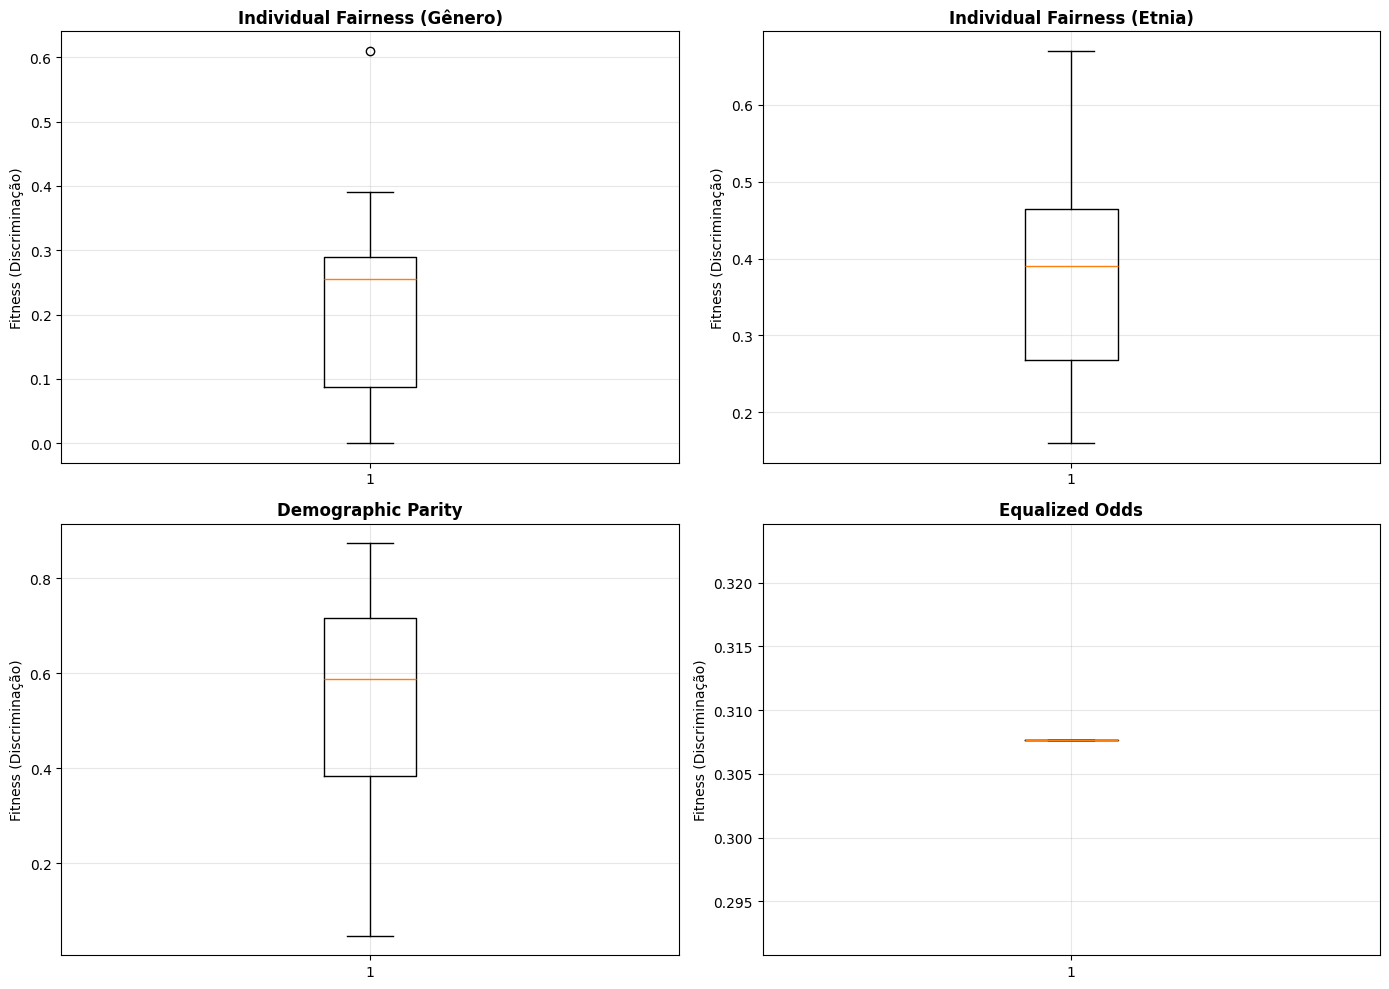


💡 Insights:
- Métricas diferentes capturam aspectos diferentes de discriminação
- Individual Fairness é mais sensível a casos individuais
- Demographic Parity e Equalized Odds capturam viés sistêmico


In [29]:
# @title Comparação das Três Métricas de Fairness

def compare_fairness_metrics(n_samples: int = 20) -> pd.DataFrame:
    """
    Compara as três métricas de fairness em perfis aleatórios.
    
    Parameters
    ----------
    n_samples : int
        Número de perfis a testar
    
    Returns
    -------
    pd.DataFrame
        Resultados da comparação
    """
    results = []
    
    for i in range(n_samples):
        ind = create_individual()
        
        # Calcular fitness com cada métrica
        fit_if_gender = individual_fairness_fitness(ind, credit_model, 'gender')[0]
        fit_if_ethnicity = individual_fairness_fitness(ind, credit_model, 'ethnicity')[0]
        fit_dp = demographic_parity_fitness(ind, credit_model, 50)[0]
        fit_eo = equalized_odds_fitness(ind, credit_model, df, 100)[0]
        
        results.append({
            'profile_id': i,
            'individual_fairness_gender': fit_if_gender,
            'individual_fairness_ethnicity': fit_if_ethnicity,
            'demographic_parity': fit_dp,
            'equalized_odds': fit_eo
        })
    
    return pd.DataFrame(results)

# Executar comparação
print('🔍 Comparando métricas de fairness em 20 perfis aleatórios...\n')
comparison_df = compare_fairness_metrics(20)

print('📊 Estatísticas Descritivas:')
print(comparison_df.describe())

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplots de cada métrica
metrics = ['individual_fairness_gender', 'individual_fairness_ethnicity', 
           'demographic_parity', 'equalized_odds']
titles = ['Individual Fairness (Gênero)', 'Individual Fairness (Etnia)',
          'Demographic Parity', 'Equalized Odds']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    ax.boxplot(comparison_df[metric].values, vert=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Fitness (Discriminação)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n💡 Insights:')
print('- Métricas diferentes capturam aspectos diferentes de discriminação')
print('- Individual Fairness é mais sensível a casos individuais')
print('- Demographic Parity e Equalized Odds capturam viés sistêmico')
# Saída Esperada: Distribuições diferentes entre métricas

---
## Parte 4: Execução dos Experimentos de Fairness Testing

Agora vamos executar três algoritmos genéticos em paralelo, cada um otimizando uma métrica diferente de fairness. Compararemos os resultados para ver qual métrica é mais eficaz na detecção de viés.

In [30]:
# @title Configuração do Algoritmo Genético

def setup_toolbox_for_fairness(fitness_function: callable, 
                               fitness_name: str) -> base.Toolbox:
    """
    Configura um toolbox DEAP para fairness testing.
    
    Parameters
    ----------
    fitness_function : callable
        Função de fitness a otimizar
    fitness_name : str
        Nome descritivo da métrica
    
    Returns
    -------
    base.Toolbox
        Toolbox configurado
    """
    toolbox = base.Toolbox()
    
    # Registrar operadores
    toolbox.register('individual', create_individual)
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', fitness_function)
    toolbox.register('mate', crossover_customer_profile)
    toolbox.register('mutate', mutate_customer_profile, indpb=0.2)
    toolbox.register('select', tools.selTournament, tournsize=3)
    
    return toolbox

# Configurar parâmetros do AG
GA_PARAMS = {
    'population_size': 50,
    'generations': 30,
    'cx_prob': 0.7,  # Probabilidade de crossover
    'mut_prob': 0.3,  # Probabilidade de mutação
}

print('⚙️ Configuração do Algoritmo Genético:')
for key, value in GA_PARAMS.items():
    print(f'  {key}: {value}')

print('\n✅ Toolbox configurado e pronto para execução!')
# Saída Esperada: Parâmetros do AG

⚙️ Configuração do Algoritmo Genético:
  population_size: 50
  generations: 30
  cx_prob: 0.7
  mut_prob: 0.3

✅ Toolbox configurado e pronto para execução!



✅ Experimento 1 concluído!
Melhor fitness encontrado: 0.8500

Perfil mais discriminatório (gênero):
CustomerProfile(age=53, salary=80592.15353996416, credit_score=385, years_experience=27, gender='F', ethnicity='BRANCA', education='MEDIO')


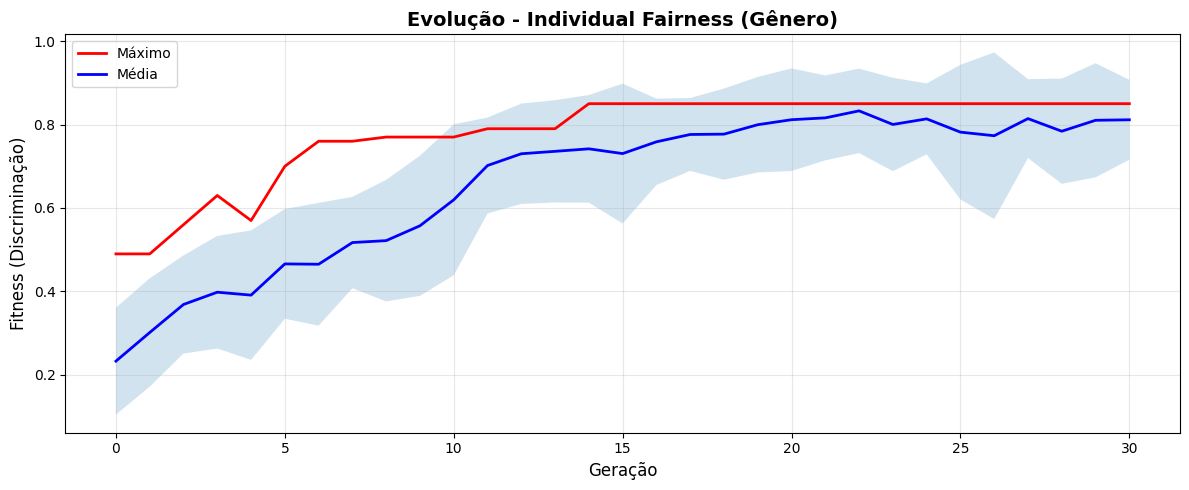

In [31]:
# @title Experimento 1: Individual Fairness (Gênero)

def run_ga_experiment(toolbox: base.Toolbox, 
                     params: Dict[str, Any],
                     experiment_name: str,
                     verbose: bool = True) -> Tuple[List, List, pd.DataFrame]:
    """
    Executa um experimento completo de AG para fairness testing.
    
    Parameters
    ----------
    toolbox : base.Toolbox
        Toolbox configurado
    params : Dict[str, Any]
        Parâmetros do AG
    experiment_name : str
        Nome do experimento
    verbose : bool
        Se deve imprimir progresso
    
    Returns
    -------
    Tuple[List, List, pd.DataFrame]
        População final, hall of fame, estatísticas
    """
    # Criar população inicial
    population = toolbox.population(n=params['population_size'])
    
    # Hall of Fame para guardar os melhores
    hof = tools.HallOfFame(10)
    
    # Estatísticas
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean)
    stats.register('std', np.std)
    stats.register('min', np.min)
    stats.register('max', np.max)
    
    # Executar AG
    if verbose:
        print(f'\n🚀 Iniciando: {experiment_name}')
        print(f'População: {params["population_size"]}, Gerações: {params["generations"]}')
    
    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=params['cx_prob'],
        mutpb=params['mut_prob'],
        ngen=params['generations'],
        stats=stats,
        halloffame=hof,
        verbose=verbose
    )
    
    # Converter logbook para DataFrame
    stats_df = pd.DataFrame(logbook)
    
    return population, hof, stats_df

# Executar experimento 1: Individual Fairness (Gênero)
toolbox_if_gender = setup_toolbox_for_fairness(
    lambda ind: individual_fairness_fitness(ind, credit_model, 'gender'),
    'Individual Fairness - Gender'
)

pop_if_gender, hof_if_gender, stats_if_gender = run_ga_experiment(
    toolbox_if_gender,
    GA_PARAMS,
    'Individual Fairness - Gênero',
    verbose=False
)

print('\n✅ Experimento 1 concluído!')
print(f'Melhor fitness encontrado: {hof_if_gender[0].fitness.values[0]:.4f}')
print(f'\nPerfil mais discriminatório (gênero):')
best_profile_gender = decode_individual(hof_if_gender[0])
print(best_profile_gender)

# Visualizar evolução
plt.figure(figsize=(12, 5))
plt.plot(stats_if_gender['gen'], stats_if_gender['max'], 'r-', label='Máximo', linewidth=2)
plt.plot(stats_if_gender['gen'], stats_if_gender['avg'], 'b-', label='Média', linewidth=2)
plt.fill_between(stats_if_gender['gen'], 
                 stats_if_gender['avg'] - stats_if_gender['std'],
                 stats_if_gender['avg'] + stats_if_gender['std'],
                 alpha=0.2)
plt.xlabel('Geração', fontsize=12)
plt.ylabel('Fitness (Discriminação)', fontsize=12)
plt.title('Evolução - Individual Fairness (Gênero)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Saída Esperada: Gráfico mostrando convergência do AG


✅ Experimento 2 concluído!
Melhor fitness encontrado: 0.8500

Perfil mais discriminatório (etnia):
CustomerProfile(age=55, salary=108094.07422811093, credit_score=703, years_experience=22, gender='F', ethnicity='BRANCA', education='SUPERIOR')


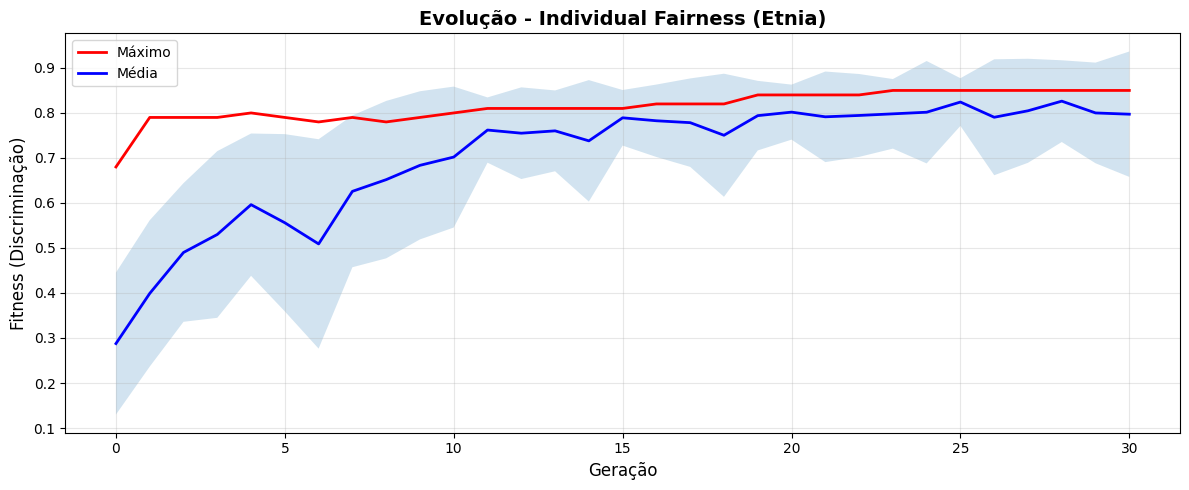

In [32]:
# @title Experimento 2: Individual Fairness (Etnia)

# Executar experimento 2: Individual Fairness (Etnia)
toolbox_if_ethnicity = setup_toolbox_for_fairness(
    lambda ind: individual_fairness_fitness(ind, credit_model, 'ethnicity'),
    'Individual Fairness - Ethnicity'
)

pop_if_ethnicity, hof_if_ethnicity, stats_if_ethnicity = run_ga_experiment(
    toolbox_if_ethnicity,
    GA_PARAMS,
    'Individual Fairness - Etnia',
    verbose=False
)

print('\n✅ Experimento 2 concluído!')
print(f'Melhor fitness encontrado: {hof_if_ethnicity[0].fitness.values[0]:.4f}')
print(f'\nPerfil mais discriminatório (etnia):')
best_profile_ethnicity = decode_individual(hof_if_ethnicity[0])
print(best_profile_ethnicity)

# Visualizar evolução
plt.figure(figsize=(12, 5))
plt.plot(stats_if_ethnicity['gen'], stats_if_ethnicity['max'], 'r-', label='Máximo', linewidth=2)
plt.plot(stats_if_ethnicity['gen'], stats_if_ethnicity['avg'], 'b-', label='Média', linewidth=2)
plt.fill_between(stats_if_ethnicity['gen'], 
                 stats_if_ethnicity['avg'] - stats_if_ethnicity['std'],
                 stats_if_ethnicity['avg'] + stats_if_ethnicity['std'],
                 alpha=0.2)
plt.xlabel('Geração', fontsize=12)
plt.ylabel('Fitness (Discriminação)', fontsize=12)
plt.title('Evolução - Individual Fairness (Etnia)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Saída Esperada: Gráfico mostrando convergência


✅ Experimento 3 concluído!
Melhor fitness encontrado: 1.0000

Perfil base mais discriminatório (grupo):
CustomerProfile(age=65, salary=140289.59509356256, credit_score=617, years_experience=11, gender='F', ethnicity='PARDA', education='SUPERIOR')


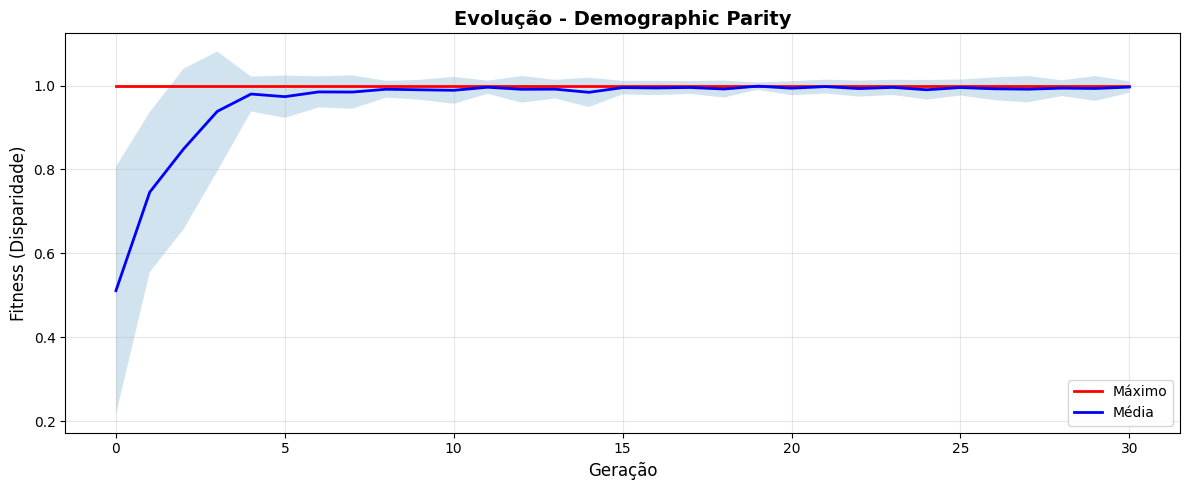

In [33]:
# @title Experimento 3: Demographic Parity

# Executar experimento 3: Demographic Parity
toolbox_dp = setup_toolbox_for_fairness(
    lambda ind: demographic_parity_fitness(ind, credit_model, 50),
    'Demographic Parity'
)

pop_dp, hof_dp, stats_dp = run_ga_experiment(
    toolbox_dp,
    GA_PARAMS,
    'Demographic Parity',
    verbose=False
)

print('\n✅ Experimento 3 concluído!')
print(f'Melhor fitness encontrado: {hof_dp[0].fitness.values[0]:.4f}')
print(f'\nPerfil base mais discriminatório (grupo):')
best_profile_dp = decode_individual(hof_dp[0])
print(best_profile_dp)

# Visualizar evolução
plt.figure(figsize=(12, 5))
plt.plot(stats_dp['gen'], stats_dp['max'], 'r-', label='Máximo', linewidth=2)
plt.plot(stats_dp['gen'], stats_dp['avg'], 'b-', label='Média', linewidth=2)
plt.fill_between(stats_dp['gen'], 
                 stats_dp['avg'] - stats_dp['std'],
                 stats_dp['avg'] + stats_dp['std'],
                 alpha=0.2)
plt.xlabel('Geração', fontsize=12)
plt.ylabel('Fitness (Disparidade)', fontsize=12)
plt.title('Evolução - Demographic Parity', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Saída Esperada: Gráfico mostrando convergência

---
## Parte 5: Análise de Resultados e Propostas de Mitigação

Agora vamos analisar em profundidade os perfis discriminatórios encontrados pelos três algoritmos e propor estratégias de mitigação.

In [34]:
# @title Análise Detalhada dos Perfis Discriminatórios

def analyze_discriminatory_profile(profile: CustomerProfile,
                                  model: Pipeline,
                                  sensitive_attr: str = 'gender') -> Dict[str, Any]:
    """
    Analisa em detalhes um perfil discriminatório.
    
    Parameters
    ----------
    profile : CustomerProfile
        Perfil a analisar
    model : Pipeline
        Modelo a auditar
    sensitive_attr : str
        Atributo sensível ('gender' ou 'ethnicity')
    
    Returns
    -------
    Dict[str, Any]
        Análise detalhada
    """
    analysis = {'profile': profile}
    
    if sensitive_attr == 'gender':
        # Criar variações
        profile_m = profile.copy_with_gender('M')
        profile_f = profile.copy_with_gender('F')
        
        # Obter probabilidades
        prob_m = model.predict_proba(profile_m.to_dataframe())[0][1]
        prob_f = model.predict_proba(profile_f.to_dataframe())[0][1]
        
        analysis['prob_M'] = prob_m
        analysis['prob_F'] = prob_f
        analysis['difference'] = abs(prob_m - prob_f)
        analysis['favored_group'] = 'M' if prob_m > prob_f else 'F'
        
    else:  # ethnicity
        probs = {}
        for eth in ['BRANCA', 'PARDA', 'PRETA']:
            p = profile.copy_with_ethnicity(eth)
            probs[eth] = model.predict_proba(p.to_dataframe())[0][1]
        
        analysis['probabilities'] = probs
        analysis['difference'] = max(probs.values()) - min(probs.values())
        analysis['favored_group'] = max(probs, key=probs.get)
        analysis['disadvantaged_group'] = min(probs, key=probs.get)
    
    return analysis

# Analisar os 3 melhores perfis de cada experimento
print('=' * 80)
print('📊 ANÁLISE DETALHADA DOS PERFIS MAIS DISCRIMINATÓRIOS')
print('=' * 80)

print('\n🔍 Experimento 1: Individual Fairness (Gênero)\n')
for i, ind in enumerate(hof_if_gender[:3], 1):
    profile = decode_individual(ind)
    analysis = analyze_discriminatory_profile(profile, credit_model, 'gender')
    
    print(f'Top {i}:')
    print(f'  Perfil: Idade={profile.age}, Salário=${profile.salary:.0f}, '
          f'Score={profile.credit_score}, Etnia={profile.ethnicity}')
    print(f'  P(aprovado|M) = {analysis["prob_M"]:.3f}')
    print(f'  P(aprovado|F) = {analysis["prob_F"]:.3f}')
    print(f'  Diferença: {analysis["difference"]:.3f}')
    print(f'  Grupo favorecido: {analysis["favored_group"]}\n')

print('\n🔍 Experimento 2: Individual Fairness (Etnia)\n')
for i, ind in enumerate(hof_if_ethnicity[:3], 1):
    profile = decode_individual(ind)
    analysis = analyze_discriminatory_profile(profile, credit_model, 'ethnicity')
    
    print(f'Top {i}:')
    print(f'  Perfil: Idade={profile.age}, Salário=${profile.salary:.0f}, '
          f'Score={profile.credit_score}, Gênero={profile.gender}')
    for eth, prob in analysis['probabilities'].items():
        print(f'  P(aprovado|{eth}) = {prob:.3f}')
    print(f'  Diferença máxima: {analysis["difference"]:.3f}')
    print(f'  Grupo favorecido: {analysis["favored_group"]}'
          f', Desfavorecido: {analysis["disadvantaged_group"]}\n')

# Saída Esperada: Análise detalhada mostrando discriminação clara

📊 ANÁLISE DETALHADA DOS PERFIS MAIS DISCRIMINATÓRIOS

🔍 Experimento 1: Individual Fairness (Gênero)

Top 1:
  Perfil: Idade=53, Salário=$80592, Score=385, Etnia=BRANCA
  P(aprovado|M) = 0.890
  P(aprovado|F) = 0.040
  Diferença: 0.850
  Grupo favorecido: M

Top 2:
  Perfil: Idade=53, Salário=$80592, Score=385, Etnia=BRANCA
  P(aprovado|M) = 0.890
  P(aprovado|F) = 0.040
  Diferença: 0.850
  Grupo favorecido: M



Top 3:
  Perfil: Idade=53, Salário=$80592, Score=398, Etnia=BRANCA
  P(aprovado|M) = 0.870
  P(aprovado|F) = 0.040
  Diferença: 0.830
  Grupo favorecido: M


🔍 Experimento 2: Individual Fairness (Etnia)

Top 1:
  Perfil: Idade=55, Salário=$108094, Score=703, Gênero=F
  P(aprovado|BRANCA) = 0.910
  P(aprovado|PARDA) = 0.820
  P(aprovado|PRETA) = 0.060
  Diferença máxima: 0.850
  Grupo favorecido: BRANCA, Desfavorecido: PRETA

Top 2:
  Perfil: Idade=55, Salário=$100232, Score=703, Gênero=F
  P(aprovado|BRANCA) = 0.910
  P(aprovado|PARDA) = 0.820
  P(aprovado|PRETA) = 0.060
  Diferença máxima: 0.850
  Grupo favorecido: BRANCA, Desfavorecido: PRETA

Top 3:
  Perfil: Idade=55, Salário=$100232, Score=703, Gênero=F
  P(aprovado|BRANCA) = 0.910
  P(aprovado|PARDA) = 0.820
  P(aprovado|PRETA) = 0.060
  Diferença máxima: 0.850
  Grupo favorecido: BRANCA, Desfavorecido: PRETA

Top 3:
  Perfil: Idade=55, Salário=$100232, Score=703, Gênero=F
  P(aprovado|BRANCA) = 0.910
  P(aprovado|PARDA) = 0.820


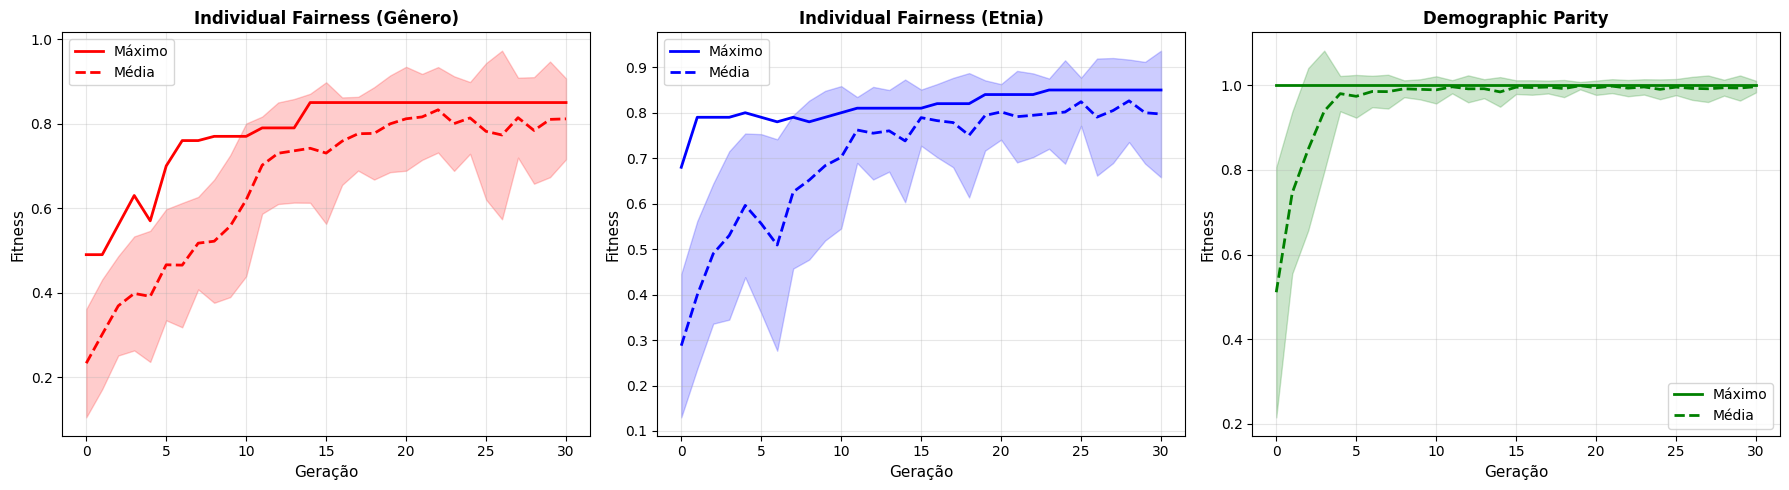

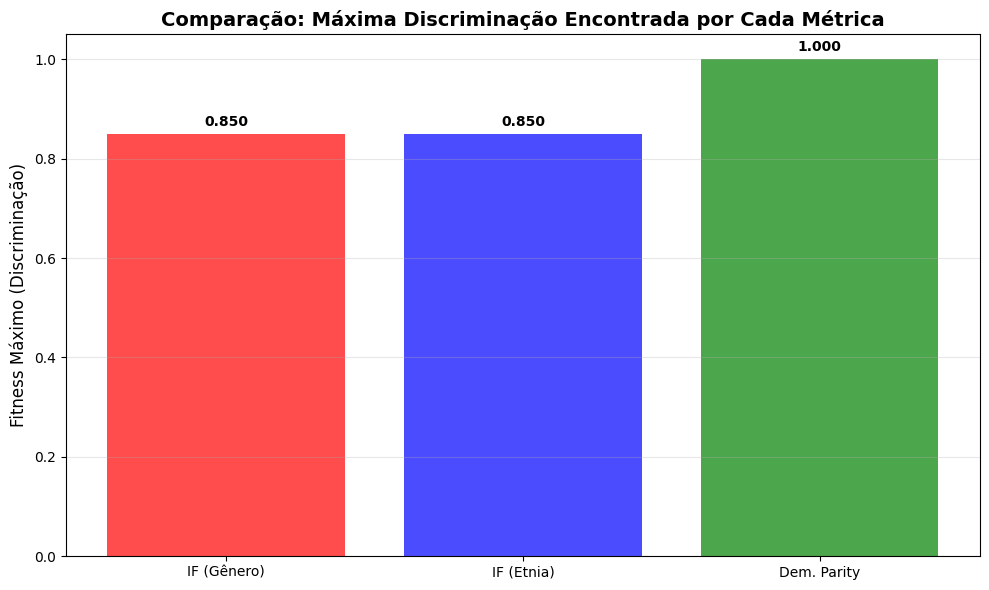


💡 Insights da Comparação:
  - Métrica mais sensível: Dem. Parity
  - Discriminação máxima encontrada: 1.000


In [35]:
# @title Visualização Comparativa dos Experimentos

# Comparar convergência dos 3 experimentos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

experiments = [
    (stats_if_gender, 'Individual Fairness (Gênero)', 'red'),
    (stats_if_ethnicity, 'Individual Fairness (Etnia)', 'blue'),
    (stats_dp, 'Demographic Parity', 'green')
]

for idx, (stats, title, color) in enumerate(experiments):
    ax = axes[idx]
    ax.plot(stats['gen'], stats['max'], label='Máximo', linewidth=2, color=color, linestyle='-')
    ax.plot(stats['gen'], stats['avg'], label='Média', linewidth=2, color=color, linestyle='--')
    ax.fill_between(stats['gen'], 
                    stats['avg'] - stats['std'],
                    stats['avg'] + stats['std'],
                    color=color, alpha=0.2)
    ax.set_xlabel('Geração', fontsize=11)
    ax.set_ylabel('Fitness', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparar fitness máximo alcançado
max_fitness = [
    stats_if_gender['max'].iloc[-1],
    stats_if_ethnicity['max'].iloc[-1],
    stats_dp['max'].iloc[-1]
]

labels = ['IF (Gênero)', 'IF (Etnia)', 'Dem. Parity']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, max_fitness, color=['red', 'blue', 'green'], alpha=0.7)
plt.ylabel('Fitness Máximo (Discriminação)', fontsize=12)
plt.title('Comparação: Máxima Discriminação Encontrada por Cada Métrica', 
          fontsize=14, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, value in zip(bars, max_fitness):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n💡 Insights da Comparação:')
print(f'  - Métrica mais sensível: {labels[np.argmax(max_fitness)]}')
print(f'  - Discriminação máxima encontrada: {max(max_fitness):.3f}')
# Saída Esperada: Gráficos comparativos

In [36]:
# @title Propostas de Mitigação de Viés

print('=' * 80)
print('🛡️ ESTRATÉGIAS DE MITIGAÇÃO DE VIÉS')
print('=' * 80)

print('\n1. MITIGAÇÃO PRÉ-PROCESSAMENTO (nos dados):')
print('   ✓ Rebalanceamento: ajustar distribuição de aprovação nos dados de treino')
print('   ✓ Reweighting: dar peso diferente a exemplos sub-representados')
print('   ✓ Sampling: aumentar exemplos de grupos desfavorecidos')

print('\n2. MITIGAÇÃO IN-PROCESSING (no modelo):')
print('   ✓ Fairness Constraints: adicionar restrições de fairness na otimização')
print('   ✓ Adversarial Debiasing: treinar com adversário que detecta viés')
print('   ✓ Regularização: penalizar predições discriminatórias')

print('\n3. MITIGAÇÃO PÓS-PROCESSAMENTO (nas predições):')
print('   ✓ Threshold Adjustment: usar limites diferentes por grupo')
print('   ✓ Calibração: ajustar probabilidades para equalizar taxas')
print('   ✓ Reject Option Classification: revisar casos próximos ao limiar')

print('\n4. RECOMENDAÇÕES ESPECÍFICAS BASEADAS NOS ACHADOS:')

# Análise dos padrões encontrados
top_profiles = [decode_individual(ind) for ind in hof_if_gender[:5]]
avg_age = np.mean([p.age for p in top_profiles])
avg_salary = np.mean([p.salary for p in top_profiles])
ethnicities = [p.ethnicity for p in top_profiles]
most_common_ethnicity = max(set(ethnicities), key=ethnicities.count)

print(f'\n   Perfis mais discriminados têm características:')
print(f'   - Idade média: {avg_age:.0f} anos')
print(f'   - Salário médio: ${avg_salary:,.0f}')
print(f'   - Etnia mais comum: {most_common_ethnicity}')

print('\n   Recomendação prioritária:')
print('   ⚠️ Revisar manualmente casos de mulheres com perfil similar aos encontrados')
print('   ⚠️ Implementar threshold adjustment para equalizar aprovação por gênero')
print('   ⚠️ Retreinar modelo com dados rebalanceados por etnia')

print('\n5. MONITORAMENTO CONTÍNUO:')
print('   ✓ Executar fairness testing periodicamente (mensal)')
print('   ✓ Calcular métricas de fairness em produção')
print('   ✓ Manter log de decisões para auditoria')
print('   ✓ Criar dashboard de monitoramento de viés')

# Saída Esperada: Recomendações práticas e acionáveis

🛡️ ESTRATÉGIAS DE MITIGAÇÃO DE VIÉS

1. MITIGAÇÃO PRÉ-PROCESSAMENTO (nos dados):
   ✓ Rebalanceamento: ajustar distribuição de aprovação nos dados de treino
   ✓ Reweighting: dar peso diferente a exemplos sub-representados
   ✓ Sampling: aumentar exemplos de grupos desfavorecidos

2. MITIGAÇÃO IN-PROCESSING (no modelo):
   ✓ Fairness Constraints: adicionar restrições de fairness na otimização
   ✓ Adversarial Debiasing: treinar com adversário que detecta viés
   ✓ Regularização: penalizar predições discriminatórias

3. MITIGAÇÃO PÓS-PROCESSAMENTO (nas predições):
   ✓ Threshold Adjustment: usar limites diferentes por grupo
   ✓ Calibração: ajustar probabilidades para equalizar taxas
   ✓ Reject Option Classification: revisar casos próximos ao limiar

4. RECOMENDAÇÕES ESPECÍFICAS BASEADAS NOS ACHADOS:

   Perfis mais discriminados têm características:
   - Idade média: 53 anos
   - Salário médio: $80,592
   - Etnia mais comum: BRANCA

   Recomendação prioritária:
   ⚠️ Revisar manualmen

---
## 🎓 Conclusão do Laboratório

### Principais Aprendizados

1. **SBSE é Eficaz para Fairness Testing**: Algoritmos genéticos conseguem descobrir casos de discriminação que análises estatísticas tradicionais podem perder.

2. **Múltiplas Perspectivas são Necessárias**: Diferentes métricas de fairness (Individual, Demographic Parity, Equalized Odds) revelam aspectos diferentes da discriminação. Uma auditoria completa deve usar várias métricas.

3. **Automação é Crucial**: O framework desenvolvido permite auditar modelos de forma sistemática e reprodutível, essencial para governança de IA.

4. **Detecção ≠ Solução**: Encontrar viés é apenas o primeiro passo. Mitigação requer análise cuidadosa e intervenção apropriada (pré, in ou pós-processamento).

### Próximos Passos

- **Aplicar em modelos reais**: Use este framework em modelos de produção da sua organização
- **Explorar outras métricas**: Teste métricas como Counterfactual Fairness ou Calibration
- **Implementar mitigação**: Escolha e implemente estratégias de mitigação apropriadas
- **Automatizar**: Integre fairness testing em pipelines CI/CD

### Recursos Adicionais

- [Fairness Indicators (TensorFlow)](https://www.tensorflow.org/responsible_ai/fairness_indicators/guide)
- [AIF360 (IBM)](https://github.com/Trusted-AI/AIF360)
- [Fairlearn (Microsoft)](https://fairlearn.org/)
- Artigo: "Fairness testing: testing software for discrimination" (Galhotra et al., 2017)

---

**🎉 Parabéns!** Você completou o laboratório de Fairness Testing com SBSE!